# HHBANK - 2 COUNTRY

In [1]:
# PACKAGES AND PATHS
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR_D = Path.cwd()

# REMOVE .parent here. cwc
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"

In [2]:
# CALIBRATION
calibration_start = {

    #==> Household parameters
    'frisch_D': 1.0,    'frisch_F': 1.0,
    'eis_D': 0.5,       'eis_F': 0.5,
    'habit_D': 0.00,    'habit_F': 0.00,
    'C_lag_D': 0.0,     'C_lag_F': 0.0,

    #==> Deposit rates (real, since pi=0 at SS)
    'rdep_D': 0.0065,   'rdep_F': 0.0062,

    #==> Bond rate (initial guess; solved endogenously via interest_rates_D/F)
    'rb_D': 0.0099,     'rb_F': 0.0075,

    #==> Government bonds
    'B_supply_D': 0.6 * 4,  'B_supply_F': 0.6 * 4,

    #==> Transfer rule parameters
    'tau_D': 0.181,         'tau_F': 0.181,
    'lamb_D': 0.85,         'lamb_F': 0.85,
    'lamb_ss_D': 0.85,      'lamb_ss_F': 0.85,
    'phi_lamb_D': 0.1,      'phi_lamb_F': 0.1,

    #==> Default parameters
    'shock_def_D': 0.000,   'shock_def_F': 0.0,
    'def_rate_D':  0.000,   'def_rate_F':  0.0,
    'def_curvature_D': 0.5, 'def_curvature_F': 0.5,
    'recovery_rate_D': 0.40,'recovery_rate_F': 0.40,

    #==> Aggregate targets
    'Y_D': 1.00,  'Y_F': 1.00,
    'N_D': 1.00,  'N_F': 1.00,
    'w_D': 0.65,  'w_F': 0.65,

    #==> Financial intermediary
    'f_D': 0.97,            'f_F': 0.97,
    'lambda_gk_D': 0.2,   'lambda_gk_F': 0.2,
    'ksi_D': 0.5,           'ksi_F': 0.5,
    'n_inter_D': 0.75 * 4,  'n_inter_F': 0.75 * 4,
    'theta_D': 4,           'theta_F': 4,

    #==> Production
    'alpha_D': 0.35,   'alpha_F': 0.35,
    'delta_D': 0.0125, 'delta_F': 0.0125,

    #==> Deposit grid
    'nZ_D': 19,       'nZ_F': 21,
    'nDep_D': 500,    'nDep_F': 500,
    'Depmax_D': 150,  'Depmax_F': 150,

    'rho_z_D': 0.9,   'rho_z_F': 0.97,
    'sigma_z_D': 0.5, 'sigma_z_F': 0.8,

    #==> Tobin's q
    'Q_D': 1.0,       'Q_F': 1.0,

    #==> Government bonds and fiscal anchors
    'b_gov_D': 0.6 * 4,    'b_gov_F': 0.6 * 4,
    'b_gov_ss_D': 0.6 * 4, 'b_gov_ss_F': 0.6 * 4,

    #==> Trade / Terms of trade
    'omega': 0.85,
    'epsilon_trade': 1.5,
    'p': 1.0,

    # ── Cross-border bond portfolio ────────────────────────────────────────────
    'phi_bF_D_ss': 0.15,  'phi_bD_F_ss': 0.20,
    'psi_bF_D':    0.05,  'psi_bD_F':    0.05,

    # ── Monetary union: single CB — all union-level params use _U suffix ──────
    'omega_union_U': 0.5,
    'i_union': 0.0065,

    # ── NK frictions — D country ──────────────────────────────────────────────
    'mu_p_D':    1.0,    'mu_w_D':    1.0,
    'kappa_p_D': 0.10,   'kappa_w_D': 0.10,
    'phi_pi_U':  1.5,    'phi_y_U':   0.125,
    'rho_i_U':   0.8,    'r_star_U':  0.0065,
    'eps_m_D':   0.0,    'Y_ss_D':    1.0,
    'pi_D':  0.0,   'pi_w_D': 0.0,
    'i_D':   0.0065,
    'mc_D':  1.0,

    # ── NK frictions — F country ──────────────────────────────────────────────
    'mu_p_F':    1.0,    'mu_w_F':    1.0,
    'kappa_p_F': 0.10,   'kappa_w_F': 0.10,
    'phi_pi_F':  1.5,    'phi_y_F':   0.125,
    'rho_i_F':   0.8,    'r_star_F':  0.0062,
    'eps_m_F':   0.0,    'Y_ss_F':    1.0,
    'pi_F':  0.0,   'pi_w_F': 0.0,
    'i_F':   0.0062,
    'mc_F':  1.0,
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9705546368050272, 'div_D': 0.141500}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9705546368050272, 'div_F': 0.141500}

In [3]:
# Bonds calibration

_phi_bF_D = calibration_start['phi_bF_D_ss']   # D banks' target share in F bonds
_phi_bD_F = calibration_start['phi_bD_F_ss']   # F banks' target share in D bonds
_n_D      = calibration_start['n_inter_D']
_n_F      = calibration_start['n_inter_F']
_B_D      = calibration_start['B_supply_D']
_B_F      = calibration_start['B_supply_F']

b_F_D_ss  = _phi_bF_D * _n_D           # D banks' F bond holdings
b_D_F_ss  = _phi_bD_F * _n_F           # F banks' D bond holdings
b_D_D_ss  = _B_D - b_D_F_ss            # D banks' domestic bonds (clearing residual)
b_F_F_ss  = _B_F - b_F_D_ss            # F banks' domestic bonds (clearing residual)

# Cross-border SS excess returns (F bonds in D, D bonds in F)
excess_return_F_D_ss = calibration_start['rdep_F'] - calibration_start['rdep_D']
excess_return_D_F_ss = calibration_start['rdep_D'] - calibration_start['rdep_F']

# Domestic bond SS portfolio weights
phi_bD_D_ss = b_D_D_ss / _n_D          # D banks' domestic bond share
phi_bF_F_ss = b_F_F_ss / _n_F          # F banks' domestic bond share

calibration_start.update({
    'b_F_D': b_F_D_ss, 'b_D_F': b_D_F_ss,
    'b_D_D': b_D_D_ss, 'b_F_F': b_F_F_ss,
    'excess_return_F_D_ss': excess_return_F_D_ss,
    'excess_return_D_F_ss': excess_return_D_F_ss,
    # Domestic bond portfolio targets (weights and adj costs)
    'phi_bD_D_ss': phi_bD_D_ss,  'phi_bF_F_ss': phi_bF_F_ss,
    'psi_bD_D': 0.05,             'psi_bF_F':    0.05,
    # Domestic bond SS excess returns — placeholder, overwritten after SS solve
    'excess_return_bD_D_ss': 0.0, 'excess_return_bF_F_ss': 0.0,
})

print(f"b_F_D_ss={b_F_D_ss:.4f}  b_D_F_ss={b_D_F_ss:.4f}")
print(f"b_D_D_ss={b_D_D_ss:.4f}  b_F_F_ss={b_F_F_ss:.4f}")
print(f"phi_bD_D_ss={phi_bD_D_ss:.4f}  phi_bF_F_ss={phi_bF_F_ss:.4f}")

b_F_D_ss=0.4500  b_D_F_ss=0.6000
b_D_D_ss=1.8000  b_F_F_ss=1.9500
phi_bD_D_ss=0.6000  phi_bF_F_ss=0.6500


In [4]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)

from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [5]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, government_ss_D, labor_ss_D,
    government_default_D, interest_rates_D, bond_return_D,
    ces_price_D, import_demand_D,
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, government_ss_F, labor_ss_F,
    government_default_F, interest_rates_F, bond_return_F,
    ces_price_F, import_demand_F,
)

from equations_global import (
    trade_balance, global_bond_market, portfolio_adj_cost,
    domestic_bond_clearing, global_goods_mkt, terms_of_trade,
)


### SOLVING MODEL

#### STEADY STATE

In [6]:
import copy

# ── Steady-state model ────────────────────────────────────────────────────────
ha = sj.create_model([
    sdf_ss_D, government_default_D, interest_rates_D, bond_return_D,
    sdf_ss_F, government_default_F, interest_rates_F, bond_return_F,

    hh_extended_D,
    smart_steady_D,
    market_clearing_D,
    steady_auxilliary_D,
    banker_div_D,
    government_ss_D,
    labor_ss_D,

    hh_extended_F,
    smart_steady_F,
    market_clearing_F,
    steady_auxilliary_F,
    banker_div_F,
    government_ss_F,
    labor_ss_F,

    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    global_bond_market,
    global_goods_mkt,
], name="MU HA Model 2 Country")

unknowns_ss = {
    'beta_D': 0.9923751817,
    'beta_F': 0.9879567578,
    'p':      1.000,
}
targets_ss = ['deposit_mkt_D', 'deposit_mkt_F', 'goods_mkt_D']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss,
                           solver='broyden_custom')

# ── Post-solve patches ────────────────────────────────────────────────────────
p_ss = float(ss['p'])

# Cross-border portfolio weights (no p-scaling in MU)
phi_bF_D_actual = float(calibration_start['b_F_D']) / float(calibration_start['n_inter_D'])
phi_bD_F_actual = float(calibration_start['b_D_F']) / float(calibration_start['n_inter_F'])

# Domestic portfolio weights and excess returns (computed from SS solution)
phi_bD_D_actual       = float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bF_F_actual       = float(ss['b_F_F']) / float(ss['n_inter_F'])
excess_return_bD_D_ss = float(ss['rb_actual_D']) - float(ss['rdep_D'])
excess_return_bF_F_ss = float(ss['rb_actual_F']) - float(ss['rdep_F'])

calibration_start.update({
    'phi_bF_D_ss': phi_bF_D_actual, 'phi_bD_F_ss': phi_bD_F_actual,
    'phi_bD_D_ss': phi_bD_D_actual, 'phi_bF_F_ss': phi_bF_F_actual,
    'excess_return_bD_D_ss': excess_return_bD_D_ss,
    'excess_return_bF_F_ss': excess_return_bF_F_ss,
    'p': p_ss,
})

for k, v in [
    ('phi_bF_D_ss', phi_bF_D_actual), ('phi_bD_F_ss', phi_bD_F_actual),
    ('phi_bD_D_ss', phi_bD_D_actual), ('phi_bF_F_ss', phi_bF_F_actual),
    ('excess_return_bD_D_ss', excess_return_bD_D_ss),
    ('excess_return_bF_F_ss', excess_return_bF_F_ss),
    ('b_F_D_res', 0.0), ('b_D_F_res', 0.0),
    ('rb_D_res',  0.0), ('rb_F_res',  0.0),   # new domestic bond FOC targets
    ('pi_D', 0.0), ('pi_F', 0.0),
    ('pi_w_D', 0.0), ('pi_w_F', 0.0),
    ('i_union',  float(ss['rdep_D'])),
    ('i_D',      float(ss['rdep_D'])),
    ('i_F',      float(ss['rdep_F'])),
    ('taylor_res_union', 0.0),
    ('mc_D', 1.0), ('mc_F', 1.0),
    ('nkpc_p_res_D', 0.0), ('nkpc_p_res_F', 0.0),
    ('nkpc_w_res_D', 0.0), ('nkpc_w_res_F', 0.0),
    ('w_res_D', 0.0), ('w_res_F', 0.0),
    ('rdep_ante_D', float(ss['rdep_D'])),
    ('rdep_ante_F', float(ss['rdep_F'])),
]:
    ss.toplevel[k] = v

ss_D = ss;  ss_F = ss;  cali_D = ss;  cali_F = ss;  cali = ss
calibration = dict(ss)
ss_final = copy.deepcopy(ss)

NFI_D = (float(ss['p']) * float(ss['rb_actual_F']) * float(calibration_start['b_F_D'])
         - float(ss['rb_actual_D']) * float(calibration_start['b_D_F']))

print(f"beta_D        = {ss['beta_D']:.10f}   beta_F = {ss['beta_F']:.10f}")
print(f"p_ss          = {ss['p']:.8f}  (solved: goods_mkt_D = 0 ↔ CA_D = 0)")
print(f"rb_D          = {ss['rb_D']:.6f}   rb_F   = {ss['rb_F']:.6f}")
print(f"rb_actual_D   = {ss['rb_actual_D']:.6f}   rb_actual_F = {ss['rb_actual_F']:.6f}")
print(f"excess_bD_D   = {excess_return_bD_D_ss:.6f}   excess_bF_F = {excess_return_bF_F_ss:.6f}")
print(f"phi_bD_D_ss   = {phi_bD_D_actual:.4f}   phi_bF_F_ss = {phi_bF_F_actual:.4f}")
print(f"NFI_D         = {NFI_D:.2e}   NX_D = {ss['NX_D']:.2e}   CA_D = {float(ss['NX_D'])+NFI_D:.2e}")
print(f"goods_mkt_D   = {ss['goods_mkt_D']:.2e}   goods_mkt_F = {ss['goods_mkt_F']:.2e}")
print(f"deposit_D     = {ss['deposit_mkt_D']:.2e}   deposit_F   = {ss['deposit_mkt_F']:.2e}")
print(f"ss_final defined ✓")

beta_D        = 0.9923742927   beta_F = 0.9879595448
p_ss          = 0.99588034  (solved: goods_mkt_D = 0 ↔ CA_D = 0)
rb_D          = 0.007684   rb_F   = 0.012187
rb_actual_D   = 0.007684   rb_actual_F = 0.012187
excess_bD_D   = 0.001184   excess_bF_F = 0.005987
phi_bD_D_ss   = 0.6000   phi_bF_F_ss = 0.6500
NFI_D         = 8.51e-04   NX_D = -1.37e-03   CA_D = -5.17e-04
goods_mkt_D   = 4.55e-15   goods_mkt_F = -1.14e-06
deposit_D     = -4.21e-13   deposit_F   = 4.97e-14
ss_final defined ✓


#### OFF STEADY-STATE EQUATIONS

In [7]:
from equations_D import (
    capital_adj_D, labor_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D, intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    domestic_bond_foc_D,   # GK-consistent domestic bond pricing (replaces interest_rates_D in full model)
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D,
    bond_return_D, sdf_D,
    fisher_D, taylor_rule_union, pricing_D, wage_setting_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F, intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    domestic_bond_foc_F,   # GK-consistent domestic bond pricing (replaces interest_rates_F in full model)
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F,
    bond_return_F, sdf_F,
    fisher_F, pricing_F, wage_setting_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_adj_cost,
    global_goods_mkt, terms_of_trade,
)

#### FULL MODEL

In [8]:
financial_solved_D = combine([
    intermediation_IC_D, intermediation_P1_D,
]).solved(
    unknowns={'nu_D': float(cali_D['nu_D']), 'eta_D': float(cali_D['eta_D'])},
    targets=['nu_res_D', 'eta_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_IC_F, intermediation_P1_F,
]).solved(
    unknowns={'nu_F': float(cali_F['nu_F']), 'eta_F': float(cali_F['eta_F'])},
    targets=['nu_res_F', 'eta_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    hh_extended_D,
    sdf_D,
    financial_solved_D,
    # interest_rates_D REMOVED: rb_D is now an unknown pinned by domestic_bond_foc_D
    government_default_D,
    bond_return_D,          # rb_actual_D = f(rb_D(-1), def_rate_D)
    bank_return_D,
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    pricing_D,
    wage_setting_D,
    fisher_D,
    banker_div_res_D,
    market_clearing_D,

    # ── Country F ──────────────────────────────────────────────────────────────
    hh_extended_F,
    sdf_F,
    financial_solved_F,
    # interest_rates_F REMOVED: rb_F is now an unknown pinned by domestic_bond_foc_F
    government_default_F,
    bond_return_F,          # rb_actual_F = f(rb_F(-1), def_rate_F)
    bank_return_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    pricing_F,
    wage_setting_F,
    fisher_F,
    banker_div_res_F,
    market_clearing_F,

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    domestic_bond_clearing,   # b_D_D = b_gov_D - b_D_F;  b_F_F = b_gov_F - b_F_D
    portfolio_adj_cost,       # pins b_F_D and b_D_F (cross-border FOCs)
    domestic_bond_foc_D,      # pins rb_D: D-banks willingly hold residual b_D_D
    domestic_bond_foc_F,      # pins rb_F: F-banks willingly hold residual b_F_F
    global_goods_mkt,
    taylor_rule_union,
], name="Full 2-Country MU HANK-NK")

# ── 26 unknowns / 26 targets ──────────────────────────────────────────────────
unknowns_tp = [
    # D (11)
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D', 'b_F_D',
    'pi_D', 'pi_w_D', 'w_D',
    # F (11)
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F', 'b_D_F',
    'pi_F', 'pi_w_F', 'w_F',
    # Global (4)
    'i_union',  # single CB nominal rate
    'p',        # terms of trade
    'rb_D',     # D-bond yield — GK bank demand = supply
    'rb_F',     # F-bond yield — GK bank demand = supply
]
targets_tp = [
    # D (11)
    'deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'nkpc_p_res_D', 'nkpc_w_res_D', 'w_res_D',
    # F (11)
    'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'nkpc_p_res_F', 'nkpc_w_res_F', 'w_res_F',
    # Global (4)
    'taylor_res_union',  # single CB pins i_union
    'goods_mkt_D',       # pins p (nonzero H_Z via C_D <- Z_D)
    'rb_D_res',          # pins rb_D: D-bank domestic bond demand = supply
    'rb_F_res',          # pins rb_F: F-bank domestic bond demand = supply
]

T = 300
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F', 'eps_m_D']

print(f"Unknowns ({len(unknowns_tp)}): {unknowns_tp}")
print(f"Targets  ({len(targets_tp)}): {targets_tp}")
print(f"\nComputing Jacobian for horizon T={T}...")
G_jac = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)
print("Jacobian computed successfully.")

Unknowns (26): ['K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'Y_D', 'b_F_D', 'pi_D', 'pi_w_D', 'w_D', 'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'Y_F', 'b_D_F', 'pi_F', 'pi_w_F', 'w_F', 'i_union', 'p', 'rb_D', 'rb_F']
Targets  (26): ['deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D', 'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res', 'nkpc_p_res_D', 'nkpc_w_res_D', 'w_res_D', 'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F', 'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res', 'nkpc_p_res_F', 'nkpc_w_res_F', 'w_res_F', 'taylor_res_union', 'goods_mkt_D', 'rb_D_res', 'rb_F_res']

Computing Jacobian for horizon T=300...
Jacobian computed successfully.


### IMPULSE RESPONSE FUNCTIONS

In [9]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=50, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    zeros = np.zeros(T_plot)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            try:
                data = irf[variables[i]][:T_plot]
            except KeyError:
                data = zeros
            ax[i].plot(data, label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

In [10]:
# ── Impulse Response Functions ────────────────────────────────────────────────  

# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

print("Computing IRF: TFP shock...")
irfs_Z_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'Z_D': dZ_D}
)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)

print("Computing IRF: default shock...")
irfs_def_D = ha_full.solve_impulse_linear(
    ss_final, unknowns_tp, targets_tp, {'shock_def_D': dShock_def_D}
)

Computing IRF: TFP shock...
Computing IRF: default shock...


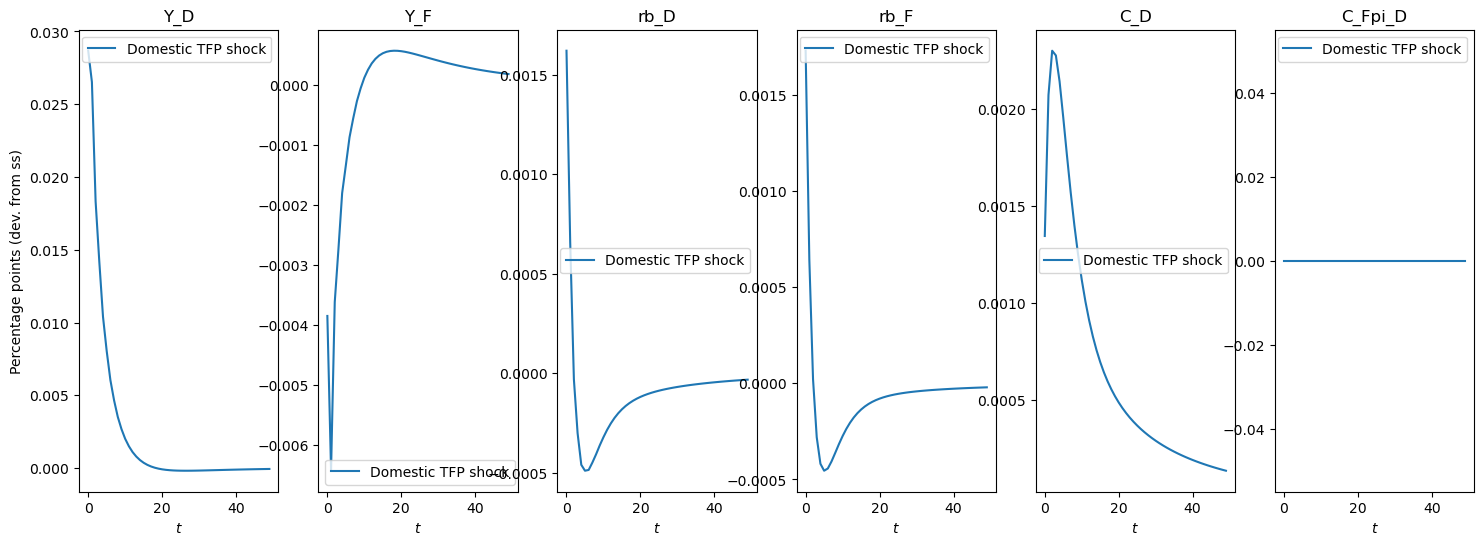

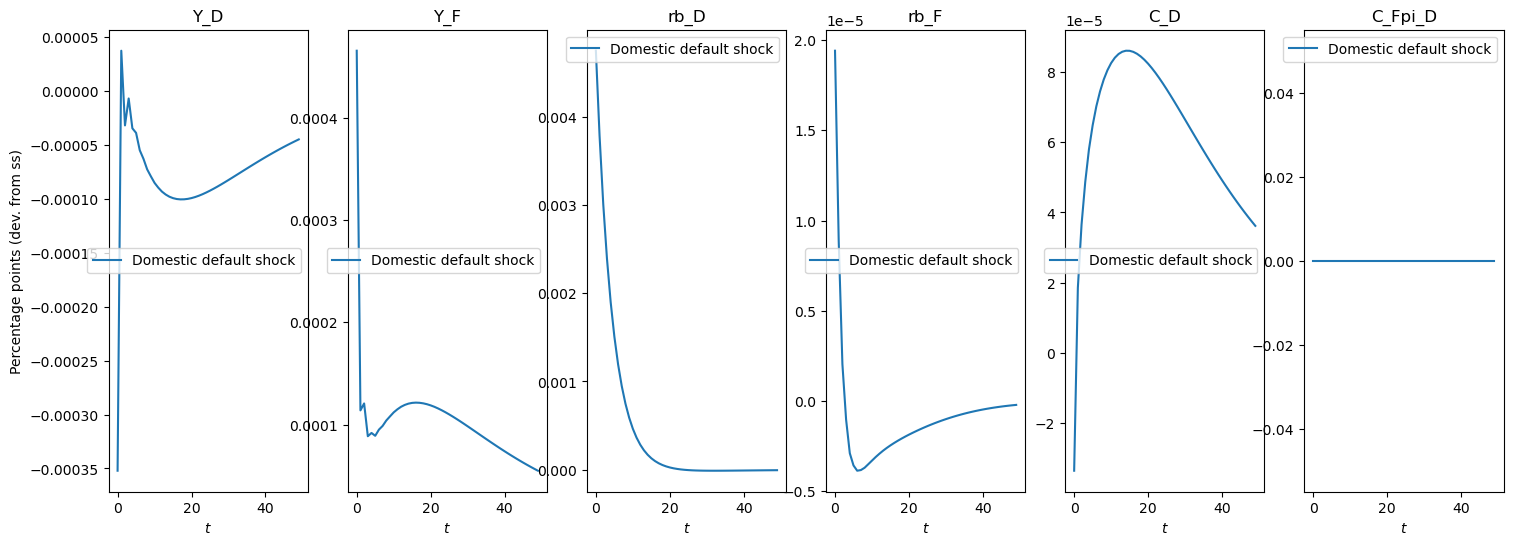

In [11]:
real = ['Z_D', 'shock_def_D', 'def_rate_D', 'Y_D', 'C_D', 'I_D', 'K_D', 'Q_D', 'N_D', 'w_D', 'iota_D', 'mpk_D', 'cap_profit_D']

financial = [
    'theta_D', 'n_inter_D', 'rn_D', 'nu_D', 'eta_D',
    'rdep_D', 'rb_D', 'rb_actual_D',
    'b_gov_D', 'DEP_D', 'D_supply_D'
]

gov = ['def_rate_D', 'shock_def_D', 'b_gov_D', 'rb_D', 'rb_actual_D', 'TAX_D', 'lamb_D', 'G_D']

residuals = [
    'goods_mkt_D', 'deposit_mkt_D', 'K_res_D', 'n_inter_val_D',
    'div_res_D', 'capital_res_D', 'q_res_D', 'b_gov_res_D',
    'labor_mkt_res_D', 'nu_res_D', 'eta_res_D'
]

# ── IMPORTANT ────────────────────────────────────────────────────────────────
important = ['Y_D', 'Y_F', 'rb_D', 'rb_F', 'C_D', 'C_F''pi_D']
show_irfs([irfs_Z_D],   important, ['Domestic TFP shock'])
show_irfs([irfs_def_D], important, ['Domestic default shock'])



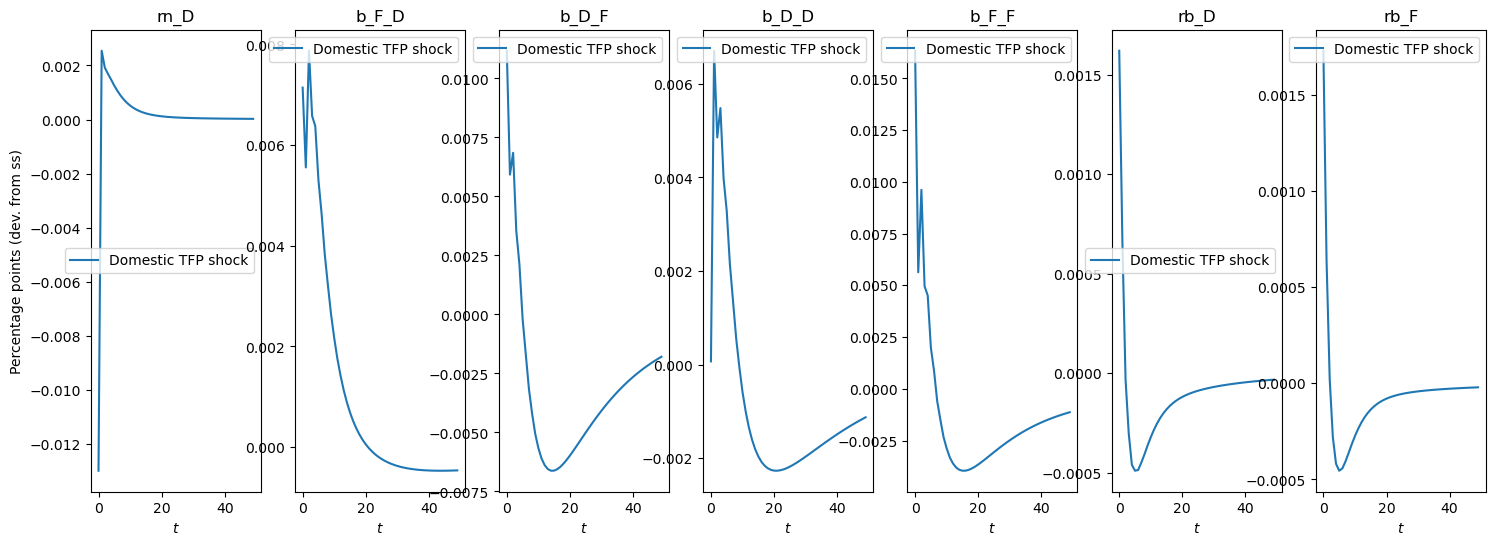

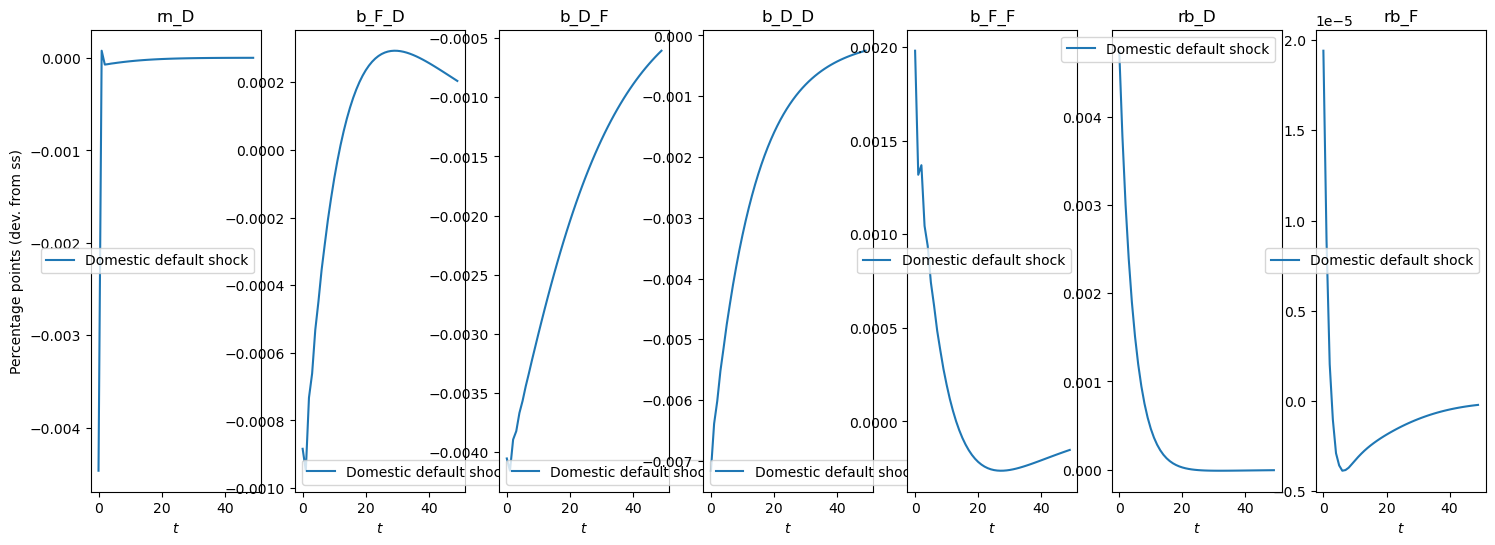

In [12]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=50, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    zeros = np.zeros(T_plot)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            try:
                data = irf[variables[i]][:T_plot]
            except KeyError:
                data = zeros
            ax[i].plot(data, label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

# ── Bond portfolio IRFs ───────────────────────────────────────────────────────
# m_D: banker entry flow (SS-only block → shows as zeros; rn_D available instead)
# b_D_D / b_F_F: from domestic_bond_clearing (residual holdings)
# b_F_D / b_D_F: cross-border holdings (unknowns_tp → nonzero IRFs)
portfolio_vars = ['rn_D', 'b_F_D', 'b_D_F', 'b_D_D', 'b_F_F', 'rb_D', 'rb_F']

show_irfs([irfs_Z_D],   portfolio_vars, ['Domestic TFP shock'])
show_irfs([irfs_def_D], portfolio_vars, ['Domestic default shock'])

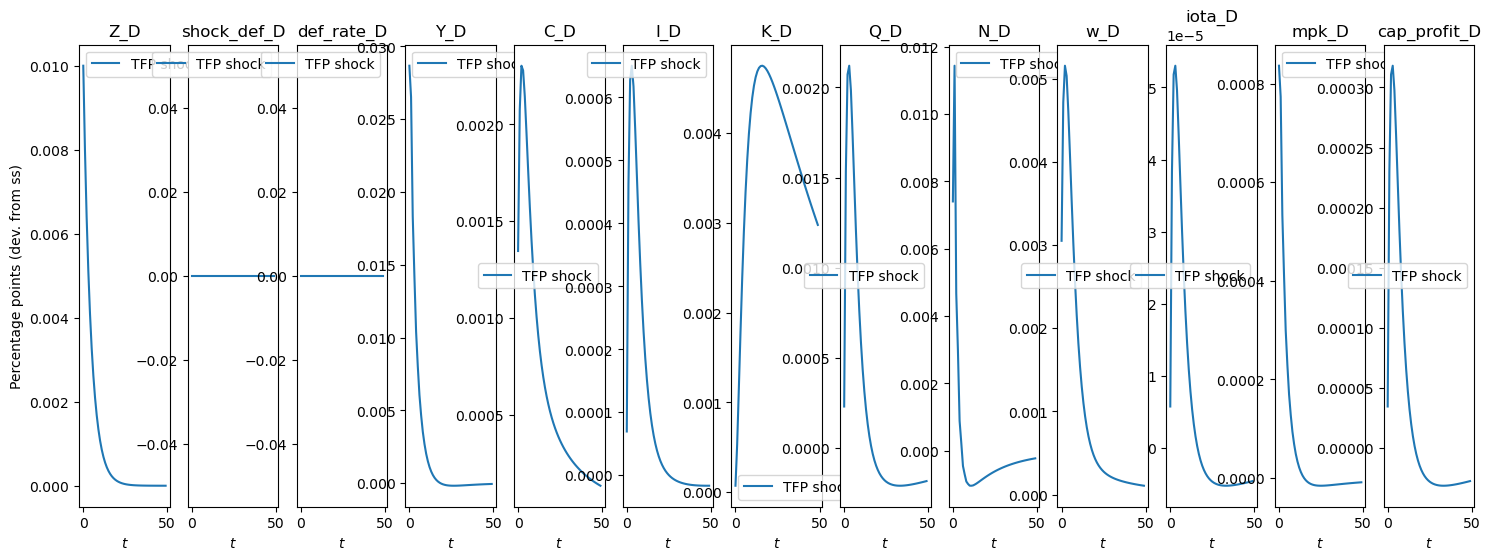

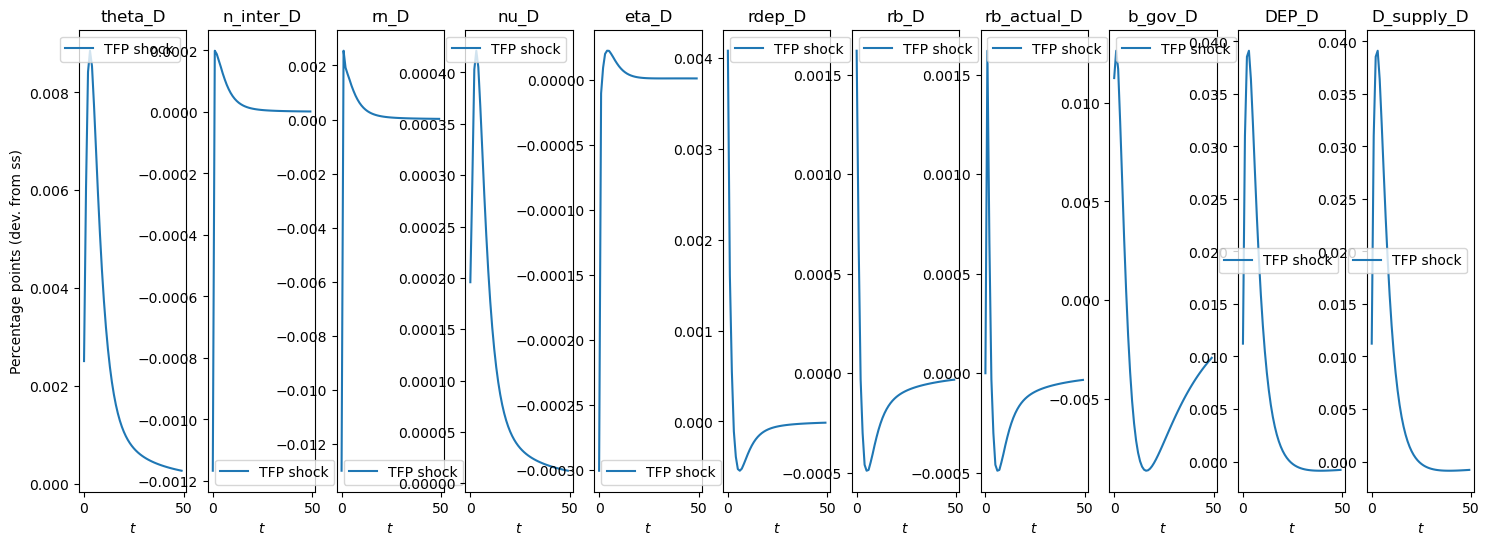

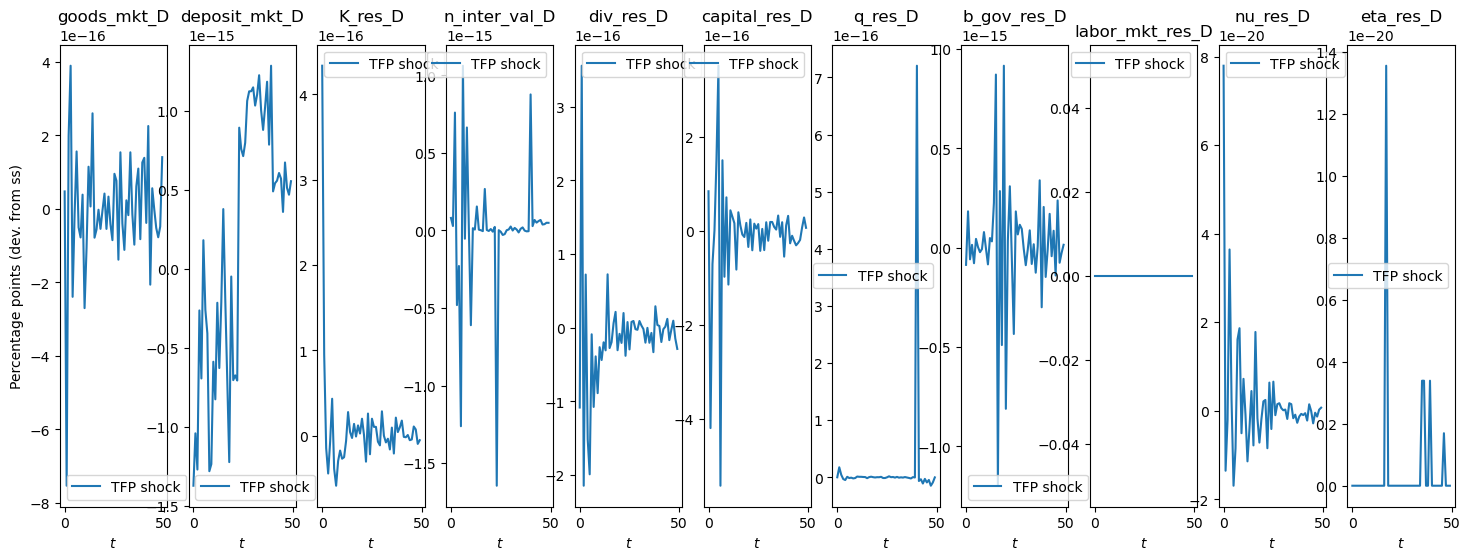

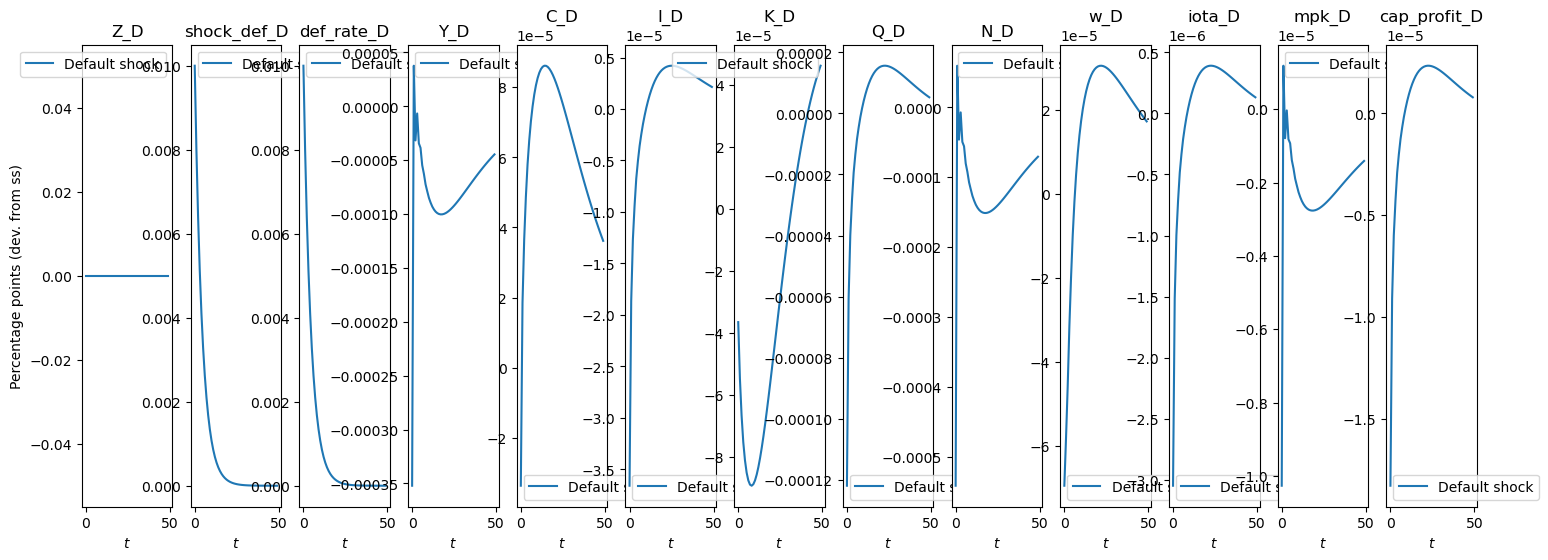

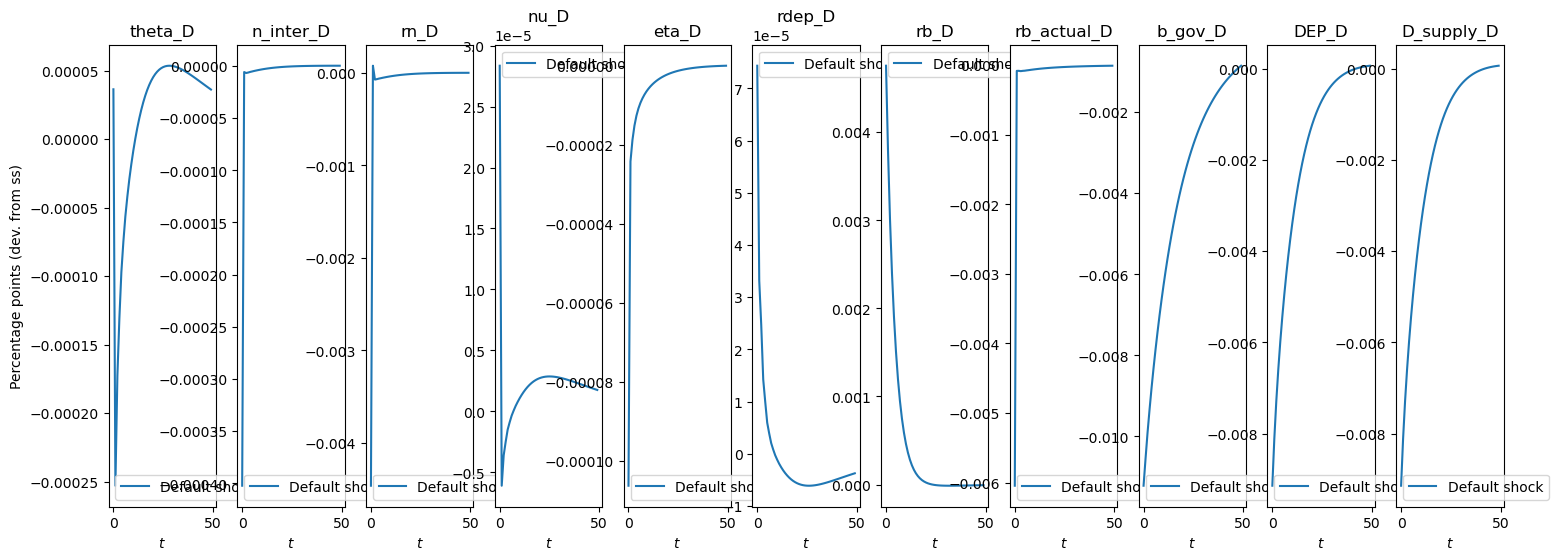

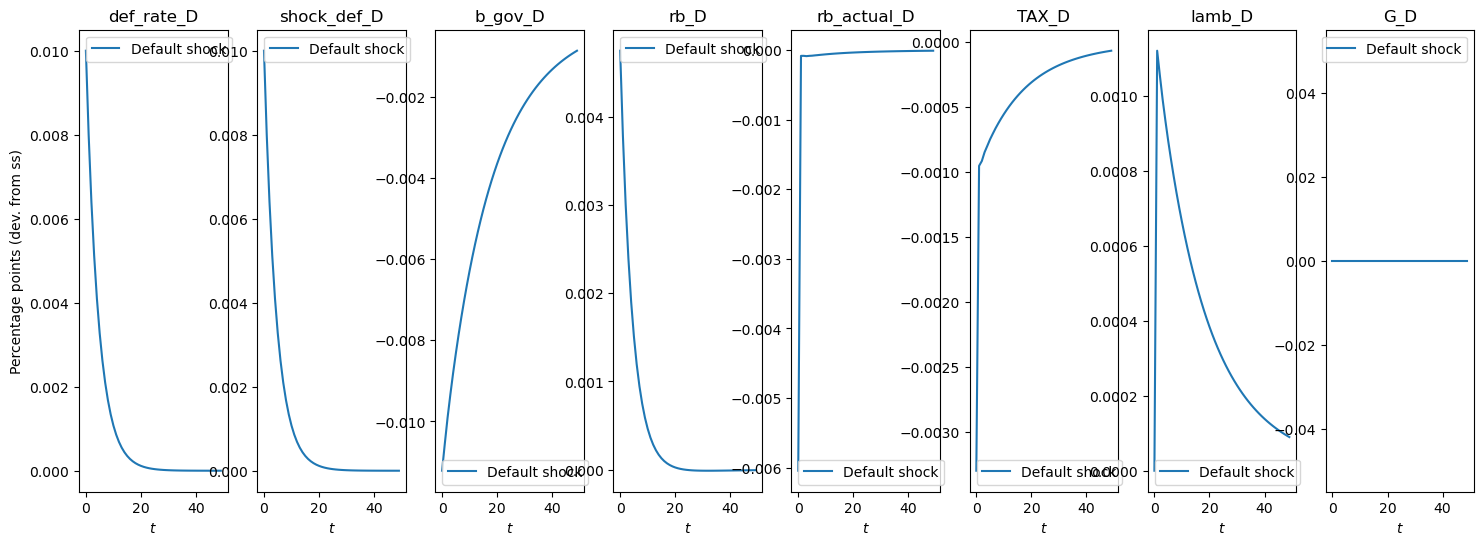

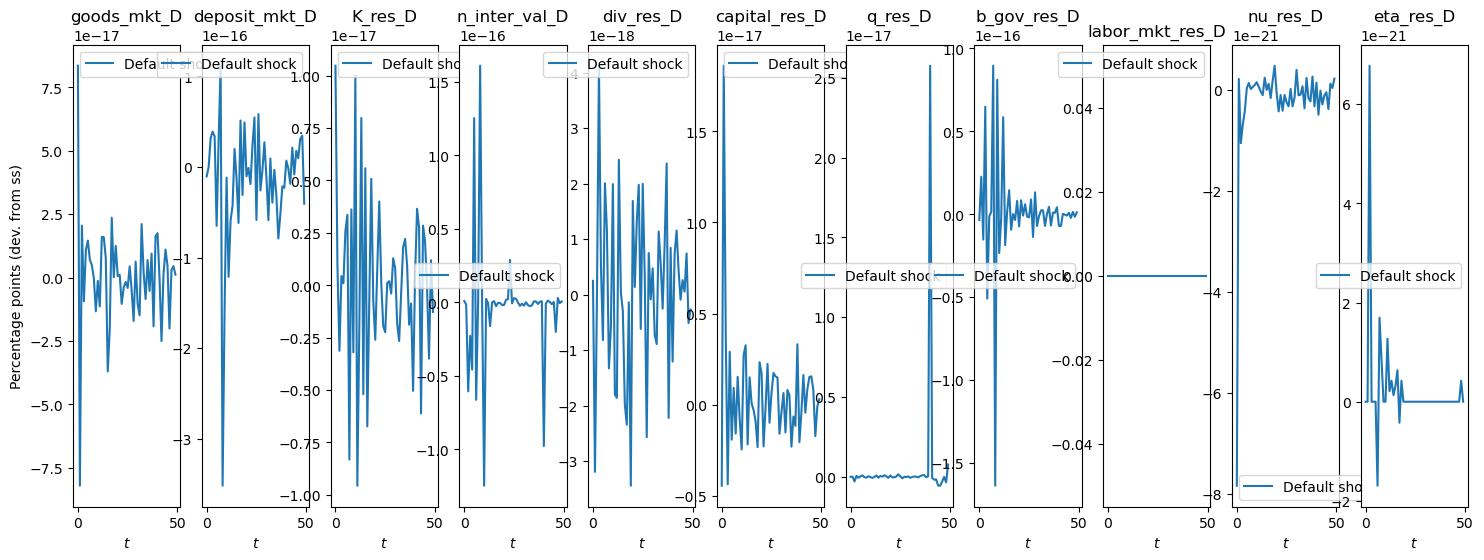

In [13]:
# ── Detailed (muted) ─────────────────────────────────────────────────────────
show_irfs([irfs_Z_D], real, ['TFP shock']) 
show_irfs([irfs_Z_D], financial, ['TFP shock'])
show_irfs([irfs_Z_D], residuals, ['TFP shock'])

show_irfs([irfs_def_D], real, ['Default shock'])
show_irfs([irfs_def_D], financial, ['Default shock']) 
show_irfs([irfs_def_D], gov, ['Default shock'])
show_irfs([irfs_def_D], residuals, ['Default shock'])

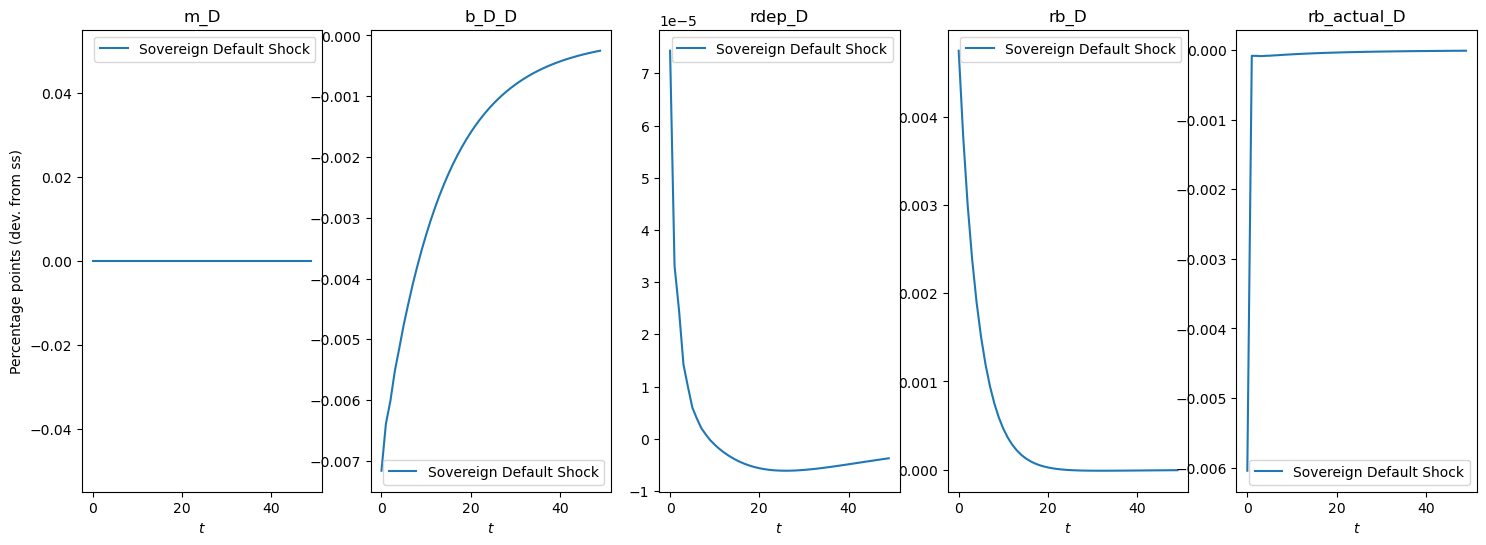

In [14]:
# Variables requested: 
# 1. Discount factor (sdf_D)
# 2. Debt holdings (b_D_D)
# 3. rdep (rdep_D) 
# 4. rb (rb_D)
# 5. rb_actual (rb_actual_D)

requested_vars = ['m_D', 'b_D_D', 'rdep_D', 'rb_D', 'rb_actual_D']

# Assuming irfs_def_D and show_irfs are already defined in the notebook
show_irfs([irfs_def_D], requested_vars, ['Sovereign Default Shock'], T_plot=50)